In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# makes all plots interactive
# this automatically displays all plots, even if we don't have plt.show()
%matplotlib widget

# 0. Process Data

In [3]:
import sys
sys.path.insert(0, '..')  # Go up from notebooks/ to project root

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.process_data import process_data
from src.plot import plot_gradients

In [5]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [6]:
BASE_DIR = Path('../data/experiment-04')
exp_dirs = sorted([d for d in BASE_DIR.iterdir() if d.is_dir() and '.ipynb' not in str(d)])

BASE_DIR = Path('../data/experiment-05')
exp_dirs += sorted([d for d in BASE_DIR.iterdir() if d.is_dir() and '.ipynb' not in str(d)])

In [7]:
# todo: why is 0 here?
canonical_mode_freqs = [53.88888888888889, 85.0, 113.05555555555556, 151.38888888888889, 196.94444444444446, 271.6666666666667, 302.77777777777777, 331.11111111111114, 363.0555555555556]

data = process_data(exp_dirs, canonical_mode_freqs=canonical_mode_freqs)
list(data.values())[0].keys()

Loaded 80 experiments


100%|██████████| 80/80 [00:16<00:00,  4.97it/s]


dict_keys(['object', 'x_position', 'y_position', 'position_xy', 'position_idx', 'duplicate_idx', 'fs', 'path', 'shifts_raw', 'time', 'shifts', 'fft_vals', 'freqs', 'mode_freqs', 'mode_freqs_idx', 'mode_fft_vals', 'synced_fft_vals', 'synced_mode_fft_vals', 'synced_fft_gradients', 'mode_fft_gradients', 'synced_mode_fft_gradients'])

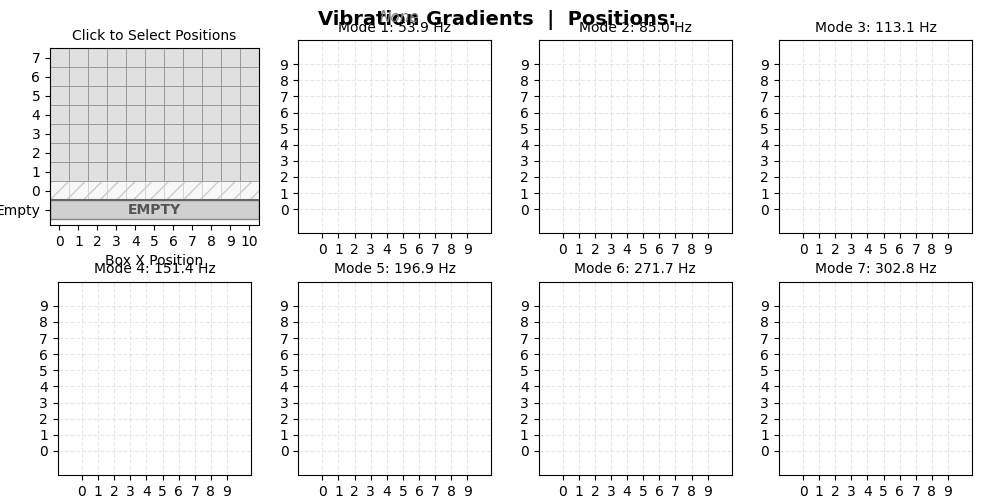

In [8]:
fig = plot_gradients(data, n_rows=2, n_cols=4)
plt.show()

# 1. Split Data

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
# remove duplicate idxs
idxs = [i for i, d in enumerate(data.values()) if d['duplicate_idx'] == 1]

# split to train, test
train_idxs, test_idxs = train_test_split(idxs, random_state=RANDOM_SEED)
data_list = list(data.items())
def partition_dict(idxs): return {data_list[idx][0] : data_list[idx][1] for idx in idxs}
train_data, test_data = partition_dict(train_idxs), partition_dict(test_idxs)

In [11]:
len(train_data), len(test_data)

(57, 20)

In [12]:
data_key = 'synced_mode_fft_vals'

X_train, X_test = np.array([np.real(d[data_key]) for d in train_data.values()]), np.array([np.real(d[data_key]) for d in test_data.values()])
X_train, X_test = X_train.reshape(X_train.shape[0], -1), X_test.reshape(X_test.shape[0], -1)

x_label_key, y_label_key = 'x_position', 'y_position'
x_label_train, x_label_test = np.array([d[x_label_key] for d in train_data.values()]), np.array([d[x_label_key] for d in test_data.values()])
y_label_train, y_label_test = np.array([d[y_label_key] for d in train_data.values()]), np.array([d[y_label_key] for d in test_data.values()])

print(f'{X_train.shape=}') # (n_samples, n_lasers * n_modes * n_coords)
print(f'{y_label_train.shape=}') # (n_samples,)

X_train.shape=(57, 1800)
y_label_train.shape=(57,)


In [13]:
def get_x_y(data_key, process='real'):
    """
    Extract features and labels for classification.

    Args:
        data_key: Which FFT data to use (e.g., 'mode_fft_vals', 'synced_fft_vals')
        process: How to process complex FFT values
            - 'real': Real component only
            - 'imaginary': Imaginary component only
            - 'magnitude': Absolute value
            - 'angle': Phase angle
            - 'real_imag': Real and imaginary concatenated
            - 'angle_mag': Angle and magnitude concatenated
    """
    def process_complex(data):
        if process == 'real':
            return np.real(data)
        elif process == 'imaginary':
            return np.imag(data)
        elif process == 'magnitude':
            return np.abs(data)
        elif process == 'angle':
            return np.angle(data)
        elif process == 'real_imag':
            return np.concatenate([np.real(data), np.imag(data)], axis=-1)
        elif process == 'angle_mag':
            return np.concatenate([np.angle(data), np.abs(data)], axis=-1)
        else:
            raise ValueError(f"Unknown process: {process}")

    X_train = np.array([process_complex(d[data_key]) for d in train_data.values()])
    X_test = np.array([process_complex(d[data_key]) for d in test_data.values()])
    X_train, X_test = X_train.reshape(X_train.shape[0], -1), X_test.reshape(X_test.shape[0], -1)

    x_label_key, y_label_key = 'x_position', 'y_position'
    x_label_train, x_label_test = np.array([d[x_label_key] for d in train_data.values()]), np.array([d[x_label_key] for d in test_data.values()])
    y_label_train, y_label_test = np.array([d[y_label_key] for d in train_data.values()]), np.array([d[y_label_key] for d in test_data.values()])

    return X_train, X_test, x_label_train, x_label_test, y_label_train, y_label_test

# 2. Classifier

In [14]:
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import root_mean_squared_error

We run RidgeClassifier experiments over all combinations of:
- **Data keys**: `mode_fft_vals`, `synced_mode_fft_vals`, `fft_vals`, `synced_fft_vals`
- **Processing methods**: `real`, `imaginary`, `magnitude`, `angle`, `real_imag`, `angle_mag`

This gives us 4 × 6 = 24 experiments to compare.

In [ ]:
# Configuration for experiments
data_keys = ['mode_fft_vals', 'synced_mode_fft_vals', 'fft_vals', 'synced_fft_vals']
processing_methods = ['real', 'imaginary', 'magnitude', 'angle', 'real_imag', 'angle_mag']

# Run all experiments
results, predictions = [], {}
for data_key in data_keys:
    # Parse data_key to extract metadata
    is_synced = 'synced' in data_key
    is_mode = 'mode' in data_key
    freq_type = 'mode (10)' if is_mode else 'all (3421)'

    for process in processing_methods:
        X_train, X_test, x_label_train, x_label_test, y_label_train, y_label_test = get_x_y(data_key, process)

        # Train and evaluate
        clf_x = RidgeClassifier(random_state=RANDOM_SEED).fit(X_train, x_label_train)
        clf_y = RidgeClassifier(random_state=RANDOM_SEED).fit(X_train, y_label_train)

        x_pred = clf_x.predict(X_test)
        y_pred = clf_y.predict(X_test)

        x_acc = clf_x.score(X_test, x_label_test)
        y_acc = clf_y.score(X_test, y_label_test)
        x_rmse = root_mean_squared_error(x_label_test, x_pred)
        y_rmse = root_mean_squared_error(y_label_test, y_pred)

        predictions[(is_mode, is_synced, process)] = {
            'x_label_test': x_label_test, 'y_label_test': y_label_test,
            'x_pred': x_pred, 'y_pred': y_pred,
            'x_acc': x_acc, 'y_acc': y_acc,
            'x_rmse': x_rmse, 'y_rmse': y_rmse,
            }

        results.append({
            'data_key': data_key,
            'frequencies': freq_type,
            'synced': is_synced,
            'processing': process,
            'n_features': X_train.shape[1],
            'x_acc': x_acc,
            'y_acc': y_acc,
            'x_rmse': x_rmse,
            'y_rmse': y_rmse,
        })

# Create DataFrame
results_df = pd.DataFrame(results)
print(f"Total test experiments: {len(results_df)}")

results_df

Total test experiments: 24


,data_key,frequencies,synced,processing,n_features,x_acc,y_acc,x_rmse,y_rmse
0,mode_fft_vals,mode (10),False,real,1800,0.50,0.10,2.073644,2.179449
1,mode_fft_vals,mode (10),False,imaginary,1800,0.40,0.10,1.788854,2.061553
2,mode_fft_vals,mode (10),False,magnitude,1800,0.80,0.25,0.591608,1.140175
3,mode_fft_vals,mode (10),False,angle,1800,0.20,0.10,3.331666,2.828427
4,mode_fft_vals,mode (10),False,real_imag,3600,0.45,0.05,2.645751,2.121320
5,mode_fft_vals,mode (10),False,angle_mag,3600,0.70,0.25,0.670820,1.431782
6,synced_mode_fft_vals,mode (10),True,real,1800,0.70,0.40,0.670820,0.866025
7,synced_mode_fft_vals,mode (10),True,imaginary,1800,0.70,0.25,0.547723,1.024695
8,synced_mode_fft_vals,mode (10),True,magnitude,1800,0.75,0.35,0.632456,0.894427
9,synced_mode_fft_vals,mode (10),True,angle,1800,0.70,0.40,1.095445,1.204159


In [50]:
# Pivot tables for accuracy
pivot_x_acc = results_df.pivot_table(values='x_acc', index=['frequencies', 'synced'], columns='processing')
pivot_y_acc = results_df.pivot_table(values='y_acc', index=['frequencies', 'synced'], columns='processing')

# Pivot tables for MSE
pivot_x_rmse = results_df.pivot_table(values='x_rmse', index=['frequencies', 'synced'], columns='processing')
pivot_y_rmse = results_df.pivot_table(values='y_rmse', index=['frequencies', 'synced'], columns='processing')

# Find best configurations
best_x_acc = results_df.loc[results_df['x_acc'].idxmax()]
best_y_acc = results_df.loc[results_df['y_acc'].idxmax()]
best_x_rmse = results_df.loc[results_df['x_rmse'].idxmin()]
best_y_rmse = results_df.loc[results_df['y_rmse'].idxmin()]

print("\nBest configurations:")
print(f"X accuracy: {best_x_acc['data_key']} + {best_x_acc['processing']} = {best_x_acc['x_acc']:.2f}")
print(f"Y accuracy: {best_y_acc['data_key']} + {best_y_acc['processing']} = {best_y_acc['y_acc']:.2f}")
print(f"X MSE:      {best_x_rmse['data_key']} + {best_x_rmse['processing']} = {best_x_rmse['x_rmse']:.2f}")
print(f"Y MSE:      {best_y_rmse['data_key']} + {best_y_rmse['processing']} = {best_y_rmse['y_rmse']:.2f}")


Best configurations:
X accuracy: fft_vals + magnitude = 0.85
Y accuracy: synced_mode_fft_vals + angle_mag = 0.50
X MSE:      fft_vals + magnitude = 0.39
Y MSE:      synced_mode_fft_vals + real_imag = 0.84


In [51]:
pivot_x_acc

processing          angle  angle_mag  imaginary  magnitude  real  real_imag
frequencies synced                                                         
all (3421)  False    0.15       0.65       0.35       0.85  0.35       0.35
            True     0.70       0.50       0.45       0.45  0.35       0.45
mode (10)   False    0.20       0.70       0.40       0.80  0.50       0.45
            True     0.70       0.70       0.70       0.75  0.70       0.70

In [52]:
pivot_y_acc

processing          angle  angle_mag  imaginary  magnitude  real  real_imag
frequencies synced                                                         
all (3421)  False     0.1       0.40       0.20       0.45  0.20       0.25
            True      0.3       0.25       0.20       0.25  0.25       0.20
mode (10)   False     0.1       0.25       0.10       0.25  0.10       0.05
            True      0.4       0.50       0.25       0.35  0.40       0.45

1. **X is much easier than Y** (0.85 vs 0.50 max) - This is surprising given Y is the distance-to-speaker axis. The lateral position (X) creates more distinguishable vibration patterns.
2. **Magnitude dominates for X** - The amplitude of vibrations is highly informative for X position, especially with all frequencies.
3. **Angle needs syncing** - Raw angle performs poorly (0.15), but synced angle jumps to 0.60-0.70. Phase information is only useful when aligned.
4. **Y benefits from combined features** - angle_mag (0.50) outperforms either alone. Y position may depend on subtle phase-amplitude relationships.
5. **Mode frequencies aren't always better** - For X+magnitude, all frequencies (0.85) beats mode frequencies (0.80). The "noise" frequencies may contain useful information.
6. **Syncing has mixed effects**:
    1. **Helps**: angle (0.15→0.70 for X), real (0.50→0.70 for X mode)
    2. **Hurts**: magnitude for all freqs (0.85→0.45 for X)


In [53]:
pivot_x_rmse

processing             angle  angle_mag  imaginary  magnitude      real  \
frequencies synced                                                        
all (3421)  False   3.612478   0.948683   2.588436   0.387298  2.559297   
            True    0.670820   1.024695   1.264911   1.500000  1.360147   
mode (10)   False   3.331666   0.670820   1.788854   0.591608  2.073644   
            True    1.095445   0.774597   0.547723   0.632456  0.670820   

processing          real_imag  
frequencies synced             
all (3421)  False    2.559297  
            True     1.204159  
mode (10)   False    2.645751  
            True     0.670820

In [54]:
pivot_y_rmse

processing             angle  angle_mag  imaginary  magnitude      real  \
frequencies synced                                                        
all (3421)  False   2.765863   1.024695   2.012461   0.921954  2.280351   
            True    0.921954   0.866025   1.161895   1.962142  1.095445   
mode (10)   False   2.828427   1.431782   2.061553   1.140175  2.179449   
            True    1.204159   1.095445   1.024695   0.894427  0.866025   

processing          real_imag  
frequencies synced             
all (3421)  False    1.910497  
            True     1.048809  
mode (10)   False    2.121320  
            True     0.836660

1. **Angle without syncing is catastrophic** - X MSE of 13.55 (mode) and 13.05 (all) means average error of ~3.6 positions. This is worse than random guessing! Syncing reduces this by 10x.

2. **Best X config confirmed** - `fft_vals` + `magnitude` + no sync achieves both best accuracy (0.85) and best MSE (0.15).

3. **Best Y config differs by metric**:
   - Best accuracy: `synced_mode_fft_vals` + `angle_mag` = 0.50 accuracy, 1.20 MSE
   - Best MSE: `synced_mode_fft_vals` + `real` = 0.40 accuracy, 0.60 MSE
   - `real` makes fewer exact matches but smaller errors when wrong.

4. **Magnitude is robust** - Consistently low MSE across all configs. A safe default choice.

5. **Combined features don't consistently help** - `real_imag` often performs similarly or worse than `real` alone. `angle_mag` helps for Y accuracy but not MSE.

6. **Syncing dramatically improves angle and imaginary**:
   - X angle MSE: 13.55 → 1.30 (mode), 13.05 → 0.45 (all)
   - X imaginary MSE: 3.20 → 0.35 (mode), 6.70 → 1.60 (all)

7. **All frequencies + no sync is high variance** - Best for magnitude (0.15 MSE) but worst for angle (13.05 MSE). The choice of processing method matters most here.


In [169]:
# Plotting utilities and color scheme
COLORS = {
    'primary': '#1f4e79',      # Dark navy
    'secondary': '#2e75b6',    # Steel blue
    'accent': '#5b9bd5',       # Light blue
    'light': '#bdd7ee',        # Pale blue
    'error': '#c55a11',        # Orange for errors
    'grid': '#d6dce5',         # Light gray-blue
}

def format_key_title(key):
    """Format experiment key tuple into readable title string."""
    is_mode, is_synced, process = key
    freq_str = "Mode Freqs" if is_mode else "All Freqs"
    sync_str = "Synced" if is_synced else "Unsynced"
    return f"{freq_str} | {sync_str} | {process.replace('_', ' ').title()}"

In [179]:
def plot_confusion_matrix(x_label_test, x_pred, y_label_test, y_pred, key,
                          x_acc=None, y_acc=None, x_rmse=None, y_rmse=None):
    """Plot confusion matrices for X and Y position predictions.

    Args:
        key: Tuple of (is_mode, is_synced, process) for title
        x_acc, y_acc: Accuracy scores
        x_rmse, y_rmse: RMSE values
    """
    from sklearn.metrics import ConfusionMatrixDisplay

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(format_key_title(key), fontsize=14, fontweight='bold', y=0.97)

    # X confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        x_label_test, x_pred, ax=axes[0],
        cmap='Blues', colorbar=False
    )
    x_title = 'X Position'
    if x_acc is not None and x_rmse is not None:
        x_title += f'\nAcc: {x_acc:.0%}  |  RMSE: {x_rmse:.2f}'
    axes[0].set_title(x_title, fontsize=12, fontweight='medium', pad=10)
    axes[0].set_xlabel('Predicted', fontsize=10)
    axes[0].set_ylabel('Actual', fontsize=10)

    # Y confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_label_test, y_pred, ax=axes[1],
        cmap='Blues', colorbar=False
    )
    y_title = 'Y Position'
    if y_acc is not None and y_rmse is not None:
        y_title += f'\nAcc: {y_acc:.0%}  |  RMSE: {y_rmse:.2f}'
    axes[1].set_title(y_title, fontsize=12, fontweight='medium', pad=10)
    axes[1].set_xlabel('Predicted', fontsize=10)
    axes[1].set_ylabel('Actual', fontsize=10)

    plt.tight_layout()
    return fig

In [190]:
def plot_grid_predictions(x_label_test, x_pred, y_label_test, y_pred, key,
                          x_acc=None, y_acc=None, x_rmse=None, y_rmse=None):
    """Plot predicted vs actual positions on a grid with error arrows.

    Args:
        key: Tuple of (is_mode, is_synced, process) for title
        x_acc, y_acc: Accuracy scores
        x_rmse, y_rmse: RMSE values
    """
    fig, ax = plt.subplots(figsize=(10, 5))

    # Calculate error metrics
    x_errors = x_pred - x_label_test
    y_errors = y_pred - y_label_test
    euclidean_dist = np.sqrt(x_errors**2 + y_errors**2)
    mean_euclidean = np.mean(euclidean_dist)

    # Background grid markers for valid positions
    for x in range(0, 11):
        for y in range(1, 8):
            ax.scatter(x, y, c=COLORS['grid'], s=200, marker='s', alpha=0.3, zorder=1)

    # Draw arrows from predicted to actual (error direction)
    for i in range(len(x_label_test)):
        if x_pred[i] != x_label_test[i] or y_pred[i] != y_label_test[i]:
            dist = euclidean_dist[i]
            alpha = min(0.9, 0.3 + dist * 0.15)  # Larger errors = more visible arrows
            ax.annotate('',
                xy=(x_label_test[i], y_label_test[i]),
                xytext=(x_pred[i], y_pred[i]),
                arrowprops=dict(arrowstyle='->', color=COLORS['secondary'],
                               alpha=alpha, lw=1.5, shrinkA=5, shrinkB=5),
                zorder=2)

    # Plot actual positions (navy filled circles)
    ax.scatter(x_label_test, y_label_test,
               c=COLORS['primary'], s=120, label='Actual',
               marker='o', edgecolors='white', linewidths=1.5, zorder=4)

    # Plot predicted positions (orange open circles)
    ax.scatter(x_pred, y_pred,
               c='none', s=100, label='Predicted',
               marker='o', edgecolors=COLORS['error'], linewidths=2, zorder=3)

    ax.set_xlabel('X Position', fontsize=11)
    ax.set_ylabel('Y Position', fontsize=11)
    ax.set_title(format_key_title(key), fontsize=14, fontweight='bold', pad=15)
    ax.legend(loc='upper right', framealpha=0.95, fontsize=10)
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(0.5, 7.5)
    ax.set_xticks(range(0, 11))
    ax.set_yticks(range(1, 8))
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2, linestyle='-', color=COLORS['grid'])

    # Stats annotation box
    stats_lines = []
    if x_acc is not None and y_acc is not None:
        stats_lines.append(f'X Acc: {x_acc:.0%}  |  Y Acc: {y_acc:.0%}')
    if x_rmse is not None and y_rmse is not None:
        stats_lines.append(f'X RMSE: {x_rmse:.2f}  |  Y RMSE: {y_rmse:.2f}')
    stats_lines.append(f'Mean Euclidean Dist: {mean_euclidean:.2f}')
    stats_text = '\n'.join(stats_lines)

    ax.text(0.02, 0.02, stats_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='bottom',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                     edgecolor=COLORS['grid'], alpha=0.9))

    plt.tight_layout()
    return fig

In [205]:
def plot_grid_predictions2(x_label_test, x_pred, y_label_test, y_pred, key,
                           x_acc=None, y_acc=None, x_rmse=None, y_rmse=None):
    """Plot predicted vs actual positions with unique colors per sample.

    Each prediction-ground truth pair gets a unique color.
    Ground truth = circle (o), Prediction = X marker.

    Args:
        key: Tuple of (is_mode, is_synced, process) for title
        x_acc, y_acc: Accuracy scores
        x_rmse, y_rmse: RMSE values
    """
    import matplotlib.cm as cm

    fig, ax = plt.subplots(figsize=(10, 5))
    n_samples = len(x_label_test)

    # Calculate error metrics
    x_errors = x_pred - x_label_test
    y_errors = y_pred - y_label_test
    euclidean_dist = np.sqrt(x_errors**2 + y_errors**2)
    mean_euclidean = np.mean(euclidean_dist)

    # Generate distinct colors using a qualitative colormap
    if n_samples <= 10:
        colors = plt.cm.tab10(np.linspace(0, 1, 10))[:n_samples]
    elif n_samples <= 20:
        colors = plt.cm.tab20(np.linspace(0, 1, 20))[:n_samples]
    else:
        colors = plt.cm.turbo(np.linspace(0.1, 0.9, n_samples))

    # Background grid markers for valid positions
    for x in range(0, 11):
        for y in range(1, 8):
            ax.scatter(x, y, c=COLORS['grid'], s=150, marker='s', alpha=0.2, zorder=1)

    # Plot each sample with its unique color
    for i in range(n_samples):
        color = colors[i]

        # Draw connecting line (if prediction != actual)
        if x_pred[i] != x_label_test[i] or y_pred[i] != y_label_test[i]:
            ax.plot([x_label_test[i], x_pred[i]], [y_label_test[i], y_pred[i]],
                   color=color, alpha=0.4, lw=1.5, zorder=2)

        # Ground truth (circle)
        ax.scatter(x_label_test[i], y_label_test[i],
                  c=[color], s=140, marker='o',
                  edgecolors='white', linewidths=1.5, zorder=4,
                  label='Actual' if i == 0 else None)

        # Prediction (X marker)
        ax.scatter(x_pred[i], y_pred[i],
                  c=[color], s=120, marker='X',
                  edgecolors='white', linewidths=0.5, zorder=3,
                  label='Predicted' if i == 0 else None)

    ax.set_xlabel('X Position', fontsize=11)
    ax.set_ylabel('Y Position', fontsize=11)
    ax.set_title(format_key_title(key), fontsize=14, fontweight='bold', pad=15)

    # Custom legend for marker types only
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
               markersize=10, label='Actual', markeredgecolor='white', markeredgewidth=1.5),
        Line2D([0], [0], marker='X', color='w', markerfacecolor='gray',
               markersize=10, label='Predicted', markeredgecolor='white', markeredgewidth=0.5),
    ]
    ax.legend(handles=legend_elements, loc='upper right', framealpha=0.95, fontsize=10)

    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(0.5, 7.5)
    ax.set_xticks(range(0, 11))
    ax.set_yticks(range(1, 8))
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.15, linestyle='-', color=COLORS['grid'])

    # Stats annotation box
    stats_lines = []
    if x_acc is not None and y_acc is not None:
        stats_lines.append(f'X Acc: {x_acc:.0%}  |  Y Acc: {y_acc:.0%}')
    if x_rmse is not None and y_rmse is not None:
        stats_lines.append(f'X RMSE: {x_rmse:.2f}  |  Y RMSE: {y_rmse:.2f}')
    stats_lines.append(f'Mean Euclidean Dist: {mean_euclidean:.2f}')
    stats_text = '\n'.join(stats_lines)

    ax.text(0.02, 0.02, stats_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='bottom',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                     edgecolor=COLORS['grid'], alpha=0.9))

    plt.tight_layout()
    return fig

In [206]:
def plot_error_distribution(x_label_test, x_pred, y_label_test, y_pred, key,
                            x_acc=None, y_acc=None, x_rmse=None, y_rmse=None):
    """Plot error distribution histograms for X and Y predictions.

    Args:
        key: Tuple of (is_mode, is_synced, process) for title
        x_acc, y_acc: Accuracy scores
        x_rmse, y_rmse: RMSE values from predictions dict
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    fig.suptitle(format_key_title(key), fontsize=14, fontweight='bold', y=0.97)

    x_errors = x_pred - x_label_test
    y_errors = y_pred - y_label_test

    # X error histogram
    axes[0].hist(x_errors, bins=np.arange(-10.5, 11.5, 1),
                 color=COLORS['accent'], edgecolor=COLORS['primary'],
                 alpha=0.8, linewidth=1.2)
    axes[0].axvline(x=0, color='#c00000', linestyle='--', lw=2, label='Perfect')
    if len(x_errors) > 0:
        axes[0].axvline(x=np.mean(x_errors), color=COLORS['secondary'],
                       linestyle='-', lw=2, label=f'Mean: {np.mean(x_errors):.2f}')
    axes[0].set_xlabel('X Prediction Error (pred − actual)', fontsize=10)
    axes[0].set_ylabel('Count', fontsize=10)

    x_title = 'X Error Distribution'
    if x_acc is not None and x_rmse is not None:
        x_title += f'\nAcc: {x_acc:.0%}  |  RMSE: {x_rmse:.2f}'
    axes[0].set_title(x_title, fontsize=11, fontweight='medium')
    axes[0].legend(loc='upper right', fontsize=9, framealpha=0.9)
    axes[0].set_xlim(-10.5, 10.5)

    # Y error histogram
    axes[1].hist(y_errors, bins=np.arange(-7.5, 8.5, 1),
                 color=COLORS['accent'], edgecolor=COLORS['primary'],
                 alpha=0.8, linewidth=1.2)
    axes[1].axvline(x=0, color='#c00000', linestyle='--', lw=2, label='Perfect')
    if len(y_errors) > 0:
        axes[1].axvline(x=np.mean(y_errors), color=COLORS['secondary'],
                       linestyle='-', lw=2, label=f'Mean: {np.mean(y_errors):.2f}')
    axes[1].set_xlabel('Y Prediction Error (pred − actual)', fontsize=10)
    axes[1].set_ylabel('Count', fontsize=10)

    y_title = 'Y Error Distribution'
    if y_acc is not None and y_rmse is not None:
        y_title += f'\nAcc: {y_acc:.0%}  |  RMSE: {y_rmse:.2f}'
    axes[1].set_title(y_title, fontsize=11, fontweight='medium')
    axes[1].legend(loc='upper right', fontsize=9, framealpha=0.9)
    axes[1].set_xlim(-7.5, 7.5)

    plt.tight_layout()
    return fig

In [207]:
is_mode = True
is_synced = True
process = 'magnitude'
key = (is_mode, is_synced, process)
prediction = predictions[key]

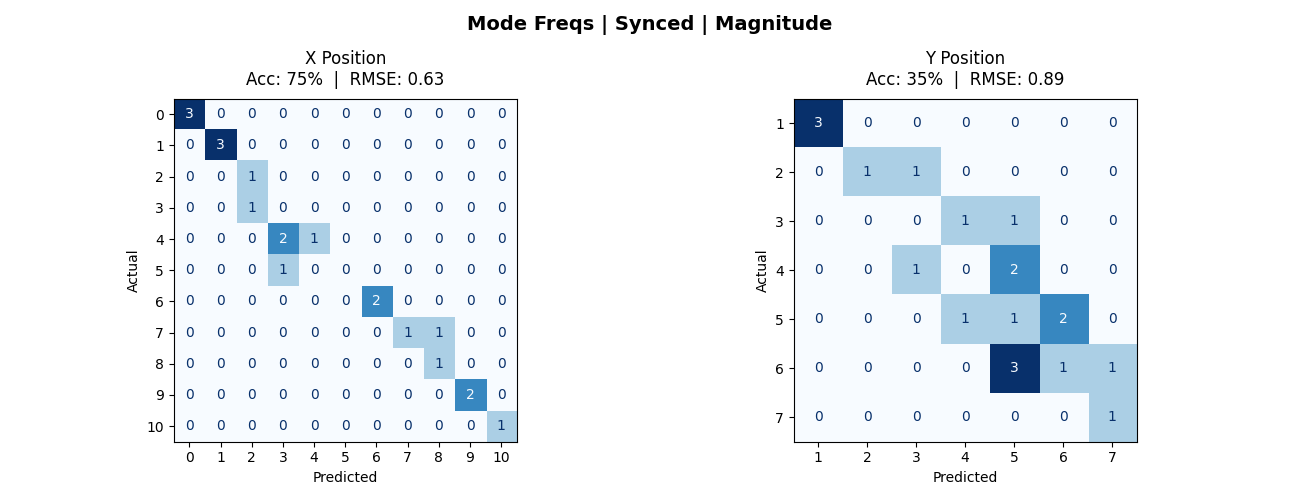

In [208]:
fig = plot_confusion_matrix(
    prediction['x_label_test'], prediction['x_pred'],
    prediction['y_label_test'], prediction['y_pred'],
    key=key,
    x_acc=prediction['x_acc'], y_acc=prediction['y_acc'],
    x_rmse=prediction['x_rmse'], y_rmse=prediction['y_rmse']
)

In [209]:
plt.close(fig)

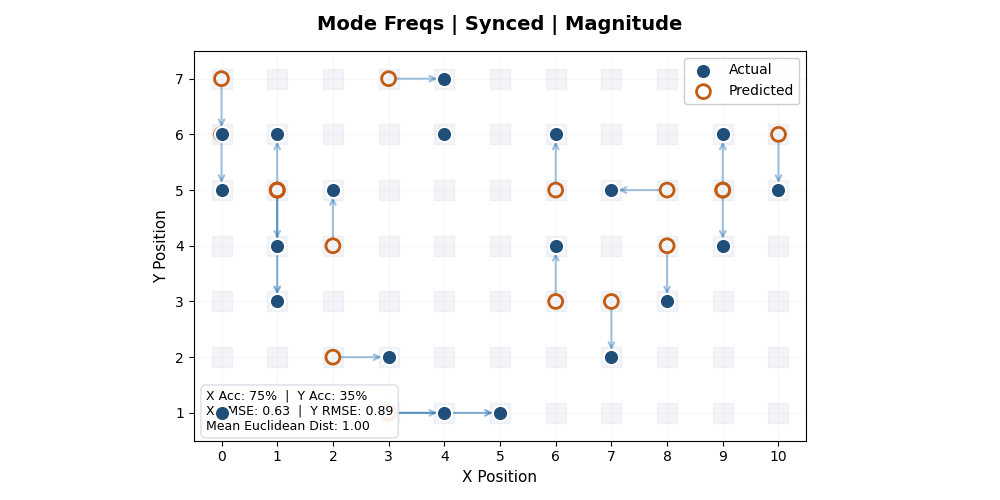

In [210]:
fig = plot_grid_predictions(
    prediction['x_label_test'], prediction['x_pred'],
    prediction['y_label_test'], prediction['y_pred'],
    key=key,
    x_acc=prediction['x_acc'], y_acc=prediction['y_acc'],
    x_rmse=prediction['x_rmse'], y_rmse=prediction['y_rmse']
)

In [211]:
plt.close(fig)

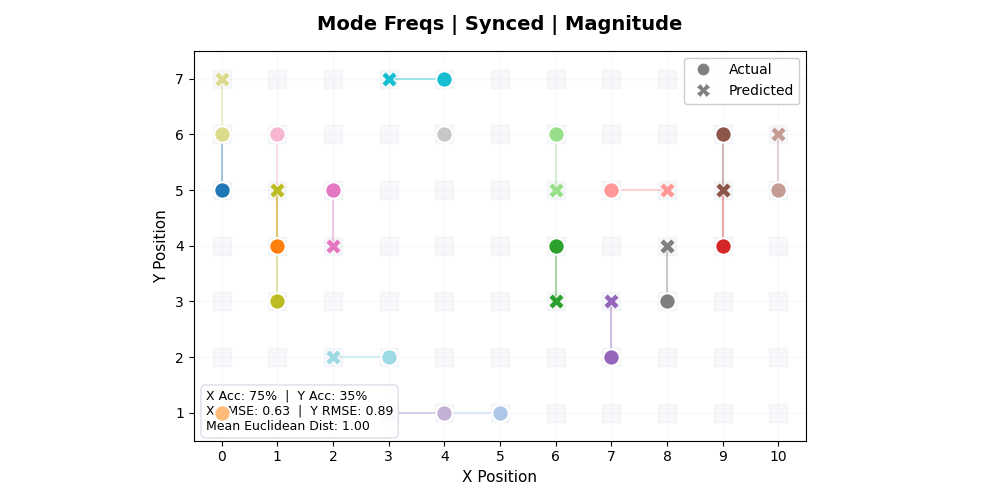

In [212]:
fig = plot_grid_predictions2(
    prediction['x_label_test'], prediction['x_pred'],
    prediction['y_label_test'], prediction['y_pred'],
    key=key,
    x_acc=prediction['x_acc'], y_acc=prediction['y_acc'],
    x_rmse=prediction['x_rmse'], y_rmse=prediction['y_rmse']
)

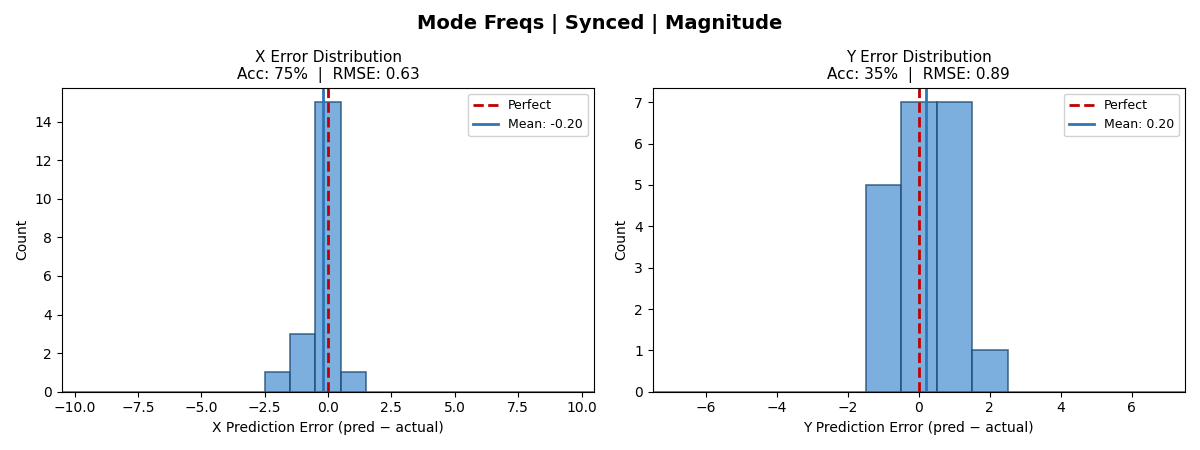

In [213]:
fig = plot_error_distribution(
    prediction['x_label_test'], prediction['x_pred'],
    prediction['y_label_test'], prediction['y_pred'],
    key=key,
    x_acc=prediction['x_acc'], y_acc=prediction['y_acc'],
    x_rmse=prediction['x_rmse'], y_rmse=prediction['y_rmse']
)

In [189]:
plt.close(fig)

### Recommendations
- **For X position**: Use `fft_vals` + `magnitude` (no sync) - clear winner on both metrics
- **For Y position**: Use `synced_mode_fft_vals` + `real` if error magnitude matters, or `angle_mag` if exact matches matter
- **Avoid**: Unsynced angle processing - catastrophically bad

# 3. Non-linear Classifer

What about using a non-linear prediction method? Let's try xgboost.

In [21]:
from xgboost import XGBClassifier

In [22]:
from sklearn.preprocessing import LabelEncoder

data_key = 'synced_fft_vals'
X_train, X_test, x_label_train, x_label_test, y_label_train, y_label_test = get_x_y(data_key)

# XGBoost requires labels starting from 0
y_encoder = LabelEncoder()
y_label_train_enc = y_encoder.fit_transform(y_label_train)
y_label_test_enc = y_encoder.transform(y_label_test)

x_encoder = LabelEncoder()
x_label_train_enc = x_encoder.fit_transform(x_label_train)
x_label_test_enc = x_encoder.transform(x_label_test)

In [23]:
# Get predictions for error analysis
clf_y = XGBClassifier(n_estimators=5, max_depth=5, learning_rate=1, random_state=RANDOM_SEED)
clf_y.fit(X_train, y_label_train_enc)
y_pred_enc = clf_y.predict(X_test)
y_pred = y_encoder.inverse_transform(y_pred_enc)
y_score = clf_y.score(X_test, y_label_test_enc)

clf_x = XGBClassifier(n_estimators=5, max_depth=5, learning_rate=1, random_state=RANDOM_SEED)
clf_x.fit(X_train, x_label_train_enc)
x_pred_enc = clf_x.predict(X_test)
x_pred = x_encoder.inverse_transform(x_pred_enc)
x_score = clf_x.score(X_test, x_label_test_enc)

print(f'{data_key} {list(data.values())[0][data_key].shape}\n{y_score=}\n{x_score=}')
print(f'X ground truth: {x_label_test}')
print(f'X  predictions: {x_pred}')
print(f'Y ground truth: {y_label_test}')
print(f'Y  predictions: {y_pred}')

synced_fft_vals (100, 3421, 2)
y_score=0.4
x_score=0.5
X ground truth: [ 0  5  1  0  6  6  9  7  7  4  9 10  2  1  8  4  1  0  4  3]
X  predictions: [ 1  6  6  0  6  6  9  7  6  1 10 10  2  1  7  4  1  1  1  2]
Y ground truth: [5 1 4 1 4 6 4 5 2 1 6 5 5 6 3 6 3 6 7 2]
Y  predictions: [4 1 2 1 6 6 3 5 2 1 6 5 4 7 5 4 2 7 4 1]


In [ ]:
# XGBoost: Define key for plotting
xgb_key = (False, True, 'real')  # synced_fft_vals with real processing (default)
x_rmse_xgb = np.sqrt(np.mean((x_pred - x_label_test)**2))
y_rmse_xgb = np.sqrt(np.mean((y_pred - y_label_test)**2))

fig = plot_grid_predictions(
    x_label_test, x_pred, y_label_test, y_pred,
    key=xgb_key,
    x_acc=x_score, y_acc=y_score,
    x_rmse=x_rmse_xgb, y_rmse=y_rmse_xgb
)
plt.show()

In [ ]:
# XGBoost error distribution (uses x_rmse_xgb, y_rmse_xgb from previous cell)
fig = plot_error_distribution(
    x_label_test, x_pred, y_label_test, y_pred,
    key=xgb_key,
    x_acc=x_score, y_acc=y_score,
    x_rmse=x_rmse_xgb, y_rmse=y_rmse_xgb
)
plt.show()

/Users/eitanturok/good-vibrations/.venv/lib/python3.12/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(
/Users/eitanturok/good-vibrations/.venv/lib/python3.12/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


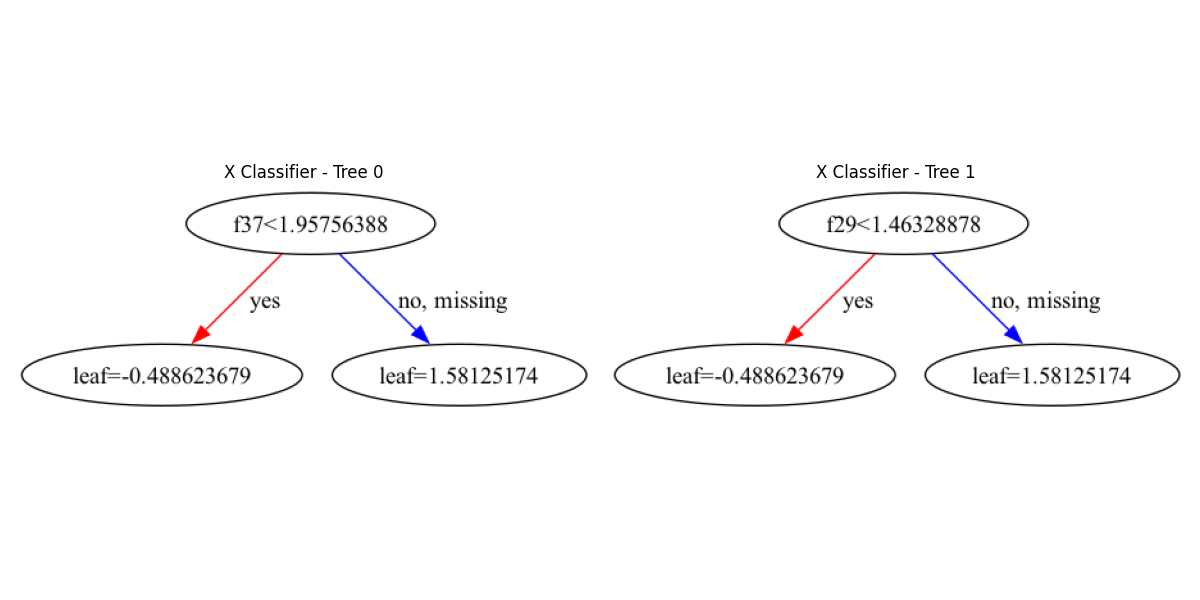

In [27]:
# Visualize XGBoost decision trees
from xgboost import plot_tree

# Plot trees for X classifier (2 trees since n_estimators=2)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_tree(clf_x, num_trees=0, ax=axes[0], rankdir='TB')
axes[0].set_title('X Classifier - Tree 0')
plot_tree(clf_x, num_trees=1, ax=axes[1], rankdir='TB')
axes[1].set_title('X Classifier - Tree 1')
plt.tight_layout()
plt.show()

/Users/eitanturok/good-vibrations/.venv/lib/python3.12/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(
/Users/eitanturok/good-vibrations/.venv/lib/python3.12/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


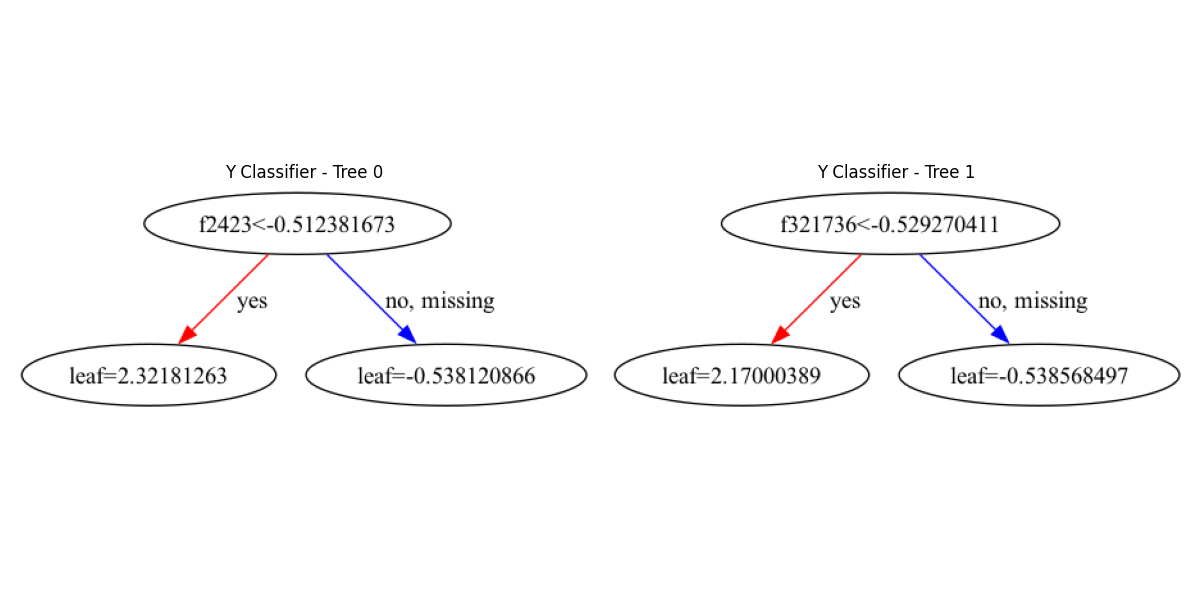

In [28]:
# Plot trees for Y classifier
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_tree(clf_y, num_trees=0, ax=axes[0], rankdir='TB')
axes[0].set_title('Y Classifier - Tree 0')
plot_tree(clf_y, num_trees=1, ax=axes[1], rankdir='TB')
axes[1].set_title('Y Classifier - Tree 1')
plt.tight_layout()
plt.show()

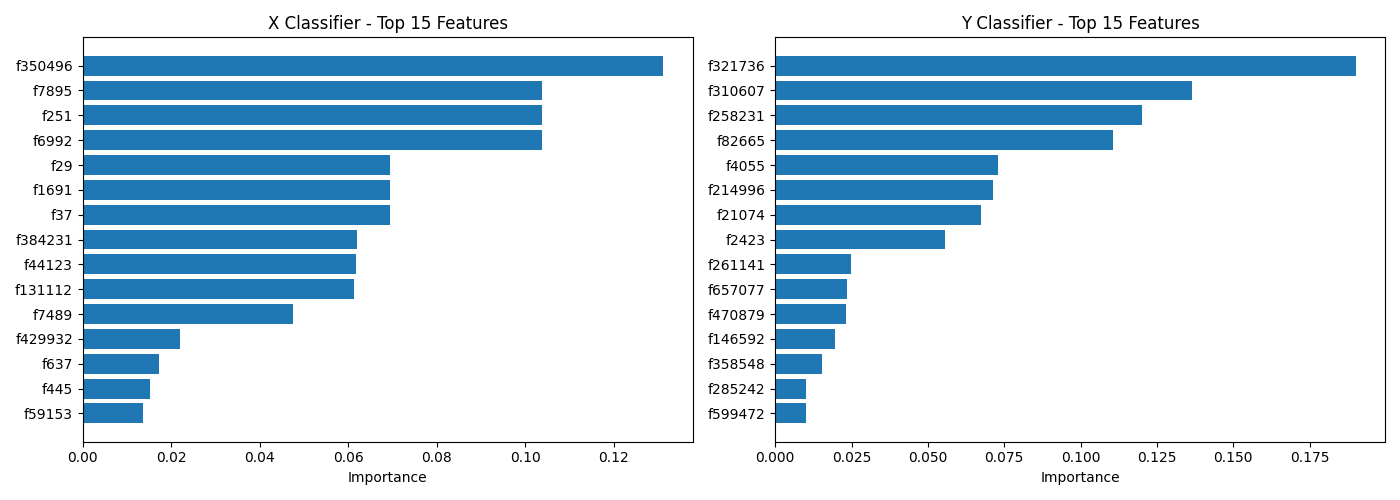

Top 5 X features:
  f350496: laser=17524, mode=8, coord=x, importance=0.1312
  f7895: laser=394, mode=7, coord=y, importance=0.1037
  f251: laser=12, mode=5, coord=y, importance=0.1037
  f6992: laser=349, mode=6, coord=x, importance=0.1037
  f29: laser=1, mode=4, coord=y, importance=0.0694

Top 5 Y features:
  f321736: laser=16086, mode=8, coord=x, importance=0.1902
  f310607: laser=15530, mode=3, coord=y, importance=0.1366
  f258231: laser=12911, mode=5, coord=y, importance=0.1202
  f82665: laser=4133, mode=2, coord=y, importance=0.1107
  f4055: laser=202, mode=7, coord=y, importance=0.0731


In [29]:
# Feature importance - which features matter most?
# Features are flattened from (100 lasers, 10 modes, 2 coords) = 2000 features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# X classifier feature importance
x_importance = clf_x.feature_importances_
top_x_idx = np.argsort(x_importance)[-15:]  # top 15 features
axes[0].barh(range(15), x_importance[top_x_idx])
axes[0].set_yticks(range(15))
axes[0].set_yticklabels([f'f{i}' for i in top_x_idx])
axes[0].set_xlabel('Importance')
axes[0].set_title('X Classifier - Top 15 Features')

# Y classifier feature importance
y_importance = clf_y.feature_importances_
top_y_idx = np.argsort(y_importance)[-15:]
axes[1].barh(range(15), y_importance[top_y_idx])
axes[1].set_yticks(range(15))
axes[1].set_yticklabels([f'f{i}' for i in top_y_idx])
axes[1].set_xlabel('Importance')
axes[1].set_title('Y Classifier - Top 15 Features')

plt.tight_layout()
plt.show()

# Decode feature indices to (laser, mode, coord)
def decode_feature(idx, n_lasers=100, n_modes=10, n_coords=2):
    coord = idx % n_coords
    mode = (idx // n_coords) % n_modes
    laser = idx // (n_coords * n_modes)
    return f'laser={laser}, mode={mode}, coord={"x" if coord==0 else "y"}'

print("Top 5 X features:")
for i in top_x_idx[-5:][::-1]:
    print(f"  f{i}: {decode_feature(i)}, importance={x_importance[i]:.4f}")

print("\nTop 5 Y features:")
for i in top_y_idx[-5:][::-1]:
    print(f"  f{i}: {decode_feature(i)}, importance={y_importance[i]:.4f}")